In [1]:
import sys
!{sys.executable} -m pip list | grep -E "ipyleaflet|geopandas|odc|pystac"

geopandas                 1.1.3
ipyleaflet                0.20.0
odc-algo                  1.1.1
odc-geo                   0.5.1
odc-io                    0.2.2
odc-loader                0.6.4
odc-stac                  0.5.2
pystac                    1.14.3
pystac-client             0.9.0


In [2]:
# Imports
# General
import sys                                   # Allows interaction with python (sys and support functions)
import os, re                                # Allows interaction with the operating system (os) and regular expression library (re)

import matplotlib.pyplot as plt              # A plotting module and convention in Python for creating 2D graphs and figures
from matplotlib import colors as mcolours    # A module for handling colours, colourmaps and normalisation.
from matplotlib.patches import Patch         # Allows creation of simple shapes (e.g., rectangles) that can be added to plots (e.g., in a legend)

from PIL import Image                        # The Python Imaging Library (PIL) for access and maniputation of images.
import io                                    # Provides tools for handling data in memory without writing to disk.

import pandas as pd
import geopandas as gpd                      # Loads the GeoPandas library with the alias being gpd.

import numpy as np                           # NumPy handles raw numerical (including multi-dimensional) arrays
import xarray as xr                          # Xarray builds on NumPY but adds labels and metadata (e.g., dimensions, coordinates). 


# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import search
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data
from esa_climate_toolbox.ops import temporal_aggregation

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import cartopy.feature as cfeature
import rasterio                       # Used to read GeoTIFF files

# Individual colormap creation
from matplotlib.colors import ListedColormap, BoundaryNorm

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

# Import year slider
from display_tools import (
    map_extent,
    year_range_slider,
    cloud_threshold_slider,
    display_da,
)

# DEA 
import odc.stac                              # Part of the Open Data Cube (ODC) ecosystem; this library is designed to work with SpatioTemporal Asset Catalogs (STAC) APIs and datasets
import pystac_client                         # Searches and queries STAC catalogs
from odc.geo import BoundingBox              # BoundingBox is a simple class for defining spatial extents
from odc.geo.cog import write_cog            # Write_cog allows you to write Cloud Optimised GeoTIFFs (COGs)
from odc.geo.xr import assign_crs            # Assign a Coordinate Reference System (CRS) to an xarray DataArray or Dataset

import ipywidgets as widgets                 # A library for creating interactive widgets in Jupyter notebooks
from IPython.display import display          # From this library, this Jupyter/IPython function renders objects in notebooks
from IPython.display import display, HTML

from odc.geo.geom import BoundingBox         # This imports the bounding box (i.e., the area of interest)

from dea_tools.plotting import display_map   # Display interactive maps
from dea_tools.landcover import lc_colourmap, make_colourbar, plot_land_cover  # Provides plotting functions specific to DEA Land Cover

In [21]:
# Define your sites and their central coordinates
sites = {
# AUSTRALIA
    "Broome, Western Australia": {"central_lat": -18.10, "central_lon": 122.32},
    "Sydney, New South Wales, Australia": {"central_lat": -33.9, "central_lon": 151.24},
    "Brisbane, Queensland, Australia": {"central_lat": -27.47, "central_lon": 153.02},
    "Redcliffe, Queensland, Australia": {"central_lat": -27.448, "central_lon": 153.1281},
    "Weipa, Queensland, Australia": {"central_lat": -12.55, "central_lon": 141.9159},
    "Lake Dundas, Western Australia, Australia": {"central_lat": -32.5792, "central_lon": 121.8507},
    "Mt Ney, Western Australia, Australia": {"central_lat": -33.1030, "central_lon": 122.7612},
    "Melbourne, Victoria, Australia": {"central_lat": -37.8250, "central_lon": 144.9344},
    "Karumba, Queensland, Australia": {"central_lat": -17.48, "central_lon": 140.8525}, 
    "Little Desert NP, Queensland, Australia": {"central_lat": -36.5, "central_lon": 141.5},
    "Perth mines, Western Australia, Australia": {"central_lat": -32.4825, "central_lon": 116.1399},
# PORTUGAL
    "Portugal": {"central_lat": 39.0, "central_lon": -8.2},

# BRAZIL
    "Amazon, Brazil": {"central_lat": -8.7494, "central_lon": -66.8848},
}

# Dropdown widget
site_dropdown = widgets.Dropdown(
    options=list(sites.keys()),
    value="Broome, Western Australia",
    description="Select site:"
)
display(site_dropdown)

Dropdown(description='Select site:', options=('Broome, Western Australia', 'Sydney, New South Wales, Australia…

In [22]:
# 🧭 Get coordinates for the currently selected site
selected_site = site_dropdown.value
central_lat = sites[selected_site]["central_lat"]
central_lon = sites[selected_site]["central_lon"]

# Now define your bounding box
buffer_lat = 0.2
buffer_lon = 0.2
crs = 'EPSG:3577'

bbox = BoundingBox(
    left=central_lon - buffer_lon,
    bottom=central_lat - buffer_lat,
    right=central_lon + buffer_lon,
    top=central_lat + buffer_lat,
    crs=crs
)
bbox_query = bbox.bbox

print(f"Bounding box for {selected_site}: "
      f"left={bbox.left:.2f}, bottom={bbox.bottom:.2f}, "
      f"right={bbox.right:.2f}, top={bbox.top:.2f}")

Bounding box for Broome, Western Australia: left=122.12, bottom=-18.30, right=122.52, top=-17.90


In [23]:
# Compute the bounding box for the study area
study_area_lat = (central_lat - buffer_lat, central_lat + buffer_lat)
study_area_lon = (central_lon - buffer_lon, central_lon + buffer_lon)
display_map(x=study_area_lon, y=study_area_lat)

### Select start and end dates

In [25]:
# Run this cell and pick a date range
years = year_range_slider()
years

IntRangeSlider(value=(2015, 2015), description='year:', max=2015, min=1992)

In [26]:
start_date = str(years.value[0])
end_date = str(years.value[1])

print("Analysed period: " + start_date + " and " + end_date)

Analysed period: 1992 and 2015


## Is the area within the Australian Bounding box?
If **yes**, you will be taken to Digital Earth Australia's STAC API.
This allows you to search for data through the STAC API (refer to the SpatioTemporal Asset Catalogue guide for details).

To load data, access to DEA's Amazon S3 buckets is configured using `odc.stac.configure_s3_access`. If launching a Dask client with `dea_tools.dask.create_local_dask_cluster()`, this is done automatically.

The advantage of accessing DEA's land cover maps is that comparisons can be made with changes observed through time-series comparisons of ESA CCI land cover.

If **no**, then you are outside of the bounding box and you will not be requested to connect.  

In [27]:
# ==========================================================
# IMPORTS
# ==========================================================
import ipywidgets as widgets
from IPython.display import display
import pystac_client
import odc.stac
import matplotlib.pyplot as plt
import io
from PIL import Image

# ==========================================================
# DEA BOUNDING BOX (Australia coverage)
# ==========================================================
DEA_BBOX = {
    "xmin": 112,
    "xmax": 154,
    "ymin": -44,
    "ymax": -10
}

def intersects_dea_bbox(minx, miny, maxx, maxy):
    return not (
        maxx < DEA_BBOX["xmin"] or
        minx > DEA_BBOX["xmax"] or
        maxy < DEA_BBOX["ymin"] or
        miny > DEA_BBOX["ymax"]
    )

# ==========================================================
# USER AOI (REPLACE THIS)
# ==========================================================
# Expecting: (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bbox

# ==========================================================
# STATUS BOX (always created only if AOI valid)
# ==========================================================
status = widgets.HTML("<b>Status:</b> Idle")

# ==========================================================
# IF AOI INVALID → STOP ENTIRE WORKFLOW
# ==========================================================
if not intersects_dea_bbox(minx, miny, maxx, maxy):

    print("❌ AOI is outside DEA (Australia) coverage.")
    print("No STAC tools loaded.")

else:

    print("✔ AOI inside DEA coverage — loading tools...")

    display(status)

    # ==========================================================
    # WIDGETS
    # ==========================================================
    enable_stac = widgets.Checkbox(
        value=False,
        description="1. Enable DEA STAC connection",
        indent=False
    )

    extract_landcover = widgets.Checkbox(
        value=False,
        description="2. Extract DEA land cover maps",
        indent=False,
        disabled=True
    )

    display(enable_stac, extract_landcover)

    catalog = None

    # ==========================================================
    # PLOT HELPER
    # ==========================================================
    def plot_to_image(func, *args, **kwargs):
        buf = io.BytesIO()
        func(*args, **kwargs)
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close()
        buf.seek(0)
        return Image.open(buf)

    # ==========================================================
    # STEP 1: CONNECT STAC
    # ==========================================================
    def connect_stac(change):

        global catalog

        if not enable_stac.value:
            catalog = None
            extract_landcover.disabled = True
            status.value = "<b>Status:</b> STAC disconnected"
            return

        status.value = "<b>Status:</b> Connecting to DEA STAC..."

        odc.stac.configure_s3_access(
            cloud_defaults=True,
            aws_unsigned=True
        )

        catalog = pystac_client.Client.open(
            "https://explorer.dea.ga.gov.au/stac"
        )

        extract_landcover.disabled = False
        status.value = "<b>Status:</b> ✔ STAC connected"

    enable_stac.observe(connect_stac, names="value")

    # ==========================================================
    # STEP 2: RUN EXTRACTION
    # ==========================================================
    def run_landcover(change):

        if not extract_landcover.value:
            return

        if catalog is None:
            status.value = "<b>Status:</b> ❌ No STAC connection"
            return

        product = "ga_ls_landcover_class_cyear_3"
        time_range = (start_date, end_date)

        # --------------------------
        # STAC SEARCH
        # --------------------------
        status.value = "<b>Status:</b> Searching STAC..."
        query = catalog.search(
            bbox=bbox,
            collections=[product],
            datetime=time_range
        )
        items = list(query.items())

        # --------------------------
        # LOAD DATA
        # --------------------------
        status.value = "<b>Status:</b> Loading DEA land cover..."
        lc = odc.stac.load(
            items,
            bands=["level3", "level4"],
            crs="EPSG:3577",
            resolution=30,
            groupby="solar_day",
            bbox=bbox
        )

        # --------------------------
        # PLOTTING
        # --------------------------
        status.value = "<b>Status:</b> Generating plots..."

        img1 = plot_to_image(plot_land_cover, lc.level3, year=start_date)
        img2 = plot_to_image(plot_land_cover, lc.level4, year=start_date)
        img3 = plot_to_image(plot_land_cover, lc.level3, year=end_date)
        img4 = plot_to_image(plot_land_cover, lc.level4, year=end_date)

        fig, axs = plt.subplots(2, 2, figsize=(12, 10))

        for ax, img in zip(axs.flat, [img1, img2, img3, img4]):
            ax.imshow(img)
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        status.value = "<b>Status:</b> ✔ Processing complete (DEA land cover extracted)"

    extract_landcover.observe(run_landcover, names="value")
    
# Plot the DEA land cover maps in a 2 x 2 grid
def plot_to_image(func, *args, **kwargs):
    buf = io.BytesIO()
    func(*args, **kwargs)  # Creates the plot
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()  # Closes the figure to make sure it is not displayed seperately
    buf.seek(0)
    return Image.open(buf)


✔ AOI inside DEA coverage — loading tools...


HTML(value='<b>Status:</b> Idle')

Checkbox(value=False, description='1. Enable DEA STAC connection', indent=False)

Checkbox(value=False, description='2. Extract DEA land cover maps', disabled=True, indent=False)

In [ ]:
#removed from cell above
#img1 = plot_to_image(plot_land_cover, lc.level3, year=start_date, width_pixels=600)
#img2 = plot_to_image(plot_land_cover, lc.level4, year=start_date, width_pixels=600)
#img3 = plot_to_image(plot_land_cover, lc.level3, year=end_date, width_pixels=600)
#img4 = plot_to_image(plot_land_cover, lc.level4, year=end_date, width_pixels=600)

#fig, axs = plt.subplots(2, 2, figsize=(12, 10))

#for ax, img in zip(axs.flat, [img1, img2, img3, img4]):
 #   ax.imshow(img)
  #  ax.axis('off')  # turn off axes

#plt.tight_layout()
#plt.show()

In [28]:
# Plot the DEA land cover maps in a 2 x 2 grid
def plot_to_image(func, *args, **kwargs):
    buf = io.BytesIO()
    func(*args, **kwargs)  # Creates the plot
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()  # Closes the figure to make sure it is not displayed seperately
    buf.seek(0)
    return Image.open(buf)

img1 = plot_to_image(plot_land_cover, lc.level3, year=start_date, width_pixels=600)
img2 = plot_to_image(plot_land_cover, lc.level4, year=start_date, width_pixels=600)
img3 = plot_to_image(plot_land_cover, lc.level3, year=end_date, width_pixels=600)
img4 = plot_to_image(plot_land_cover, lc.level4, year=end_date, width_pixels=600)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for ax, img in zip(axs.flat, [img1, img2, img3, img4]):
    ax.imshow(img)
    ax.axis('off')  # turn off axes

plt.tight_layout()
plt.show()

NameError: name 'lc' is not defined

## Connect to ESA CCI zarr store
Open the ESA CCI zarr store and list the Essential Climate Variable datasets.
Initially, focusing on land cover. You can identify the list of datasets that are available using: **list_ecv_datasets("LC")**.  
Included are high resolution 30 m maps for Siberia, Amazonia and Africa as well as global products (LCCS, Plant Functional Types).  

In [29]:
cci_zarr_store = new_data_store("esa-cci-zarr")
cci_store = new_data_store("esa-cci")

In [30]:
# from xcube.core.store import new_data_store
# cci_zarr_store = new_data_store("esa-cci-zarr")
lc_ds = cci_zarr_store.open_data(
     'ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-2015-v2.0.7b.zarr'
)
subset_spatial_op = get_op('subset_spatial')
lc_sub = subset_spatial_op(ds=lc_ds, region=bbox)
lc_sub_2d = lc_sub.isel(time=0)

## Plot DEA and ESA CCI land cover maps

Processing year 1992...
Processing year 2015...


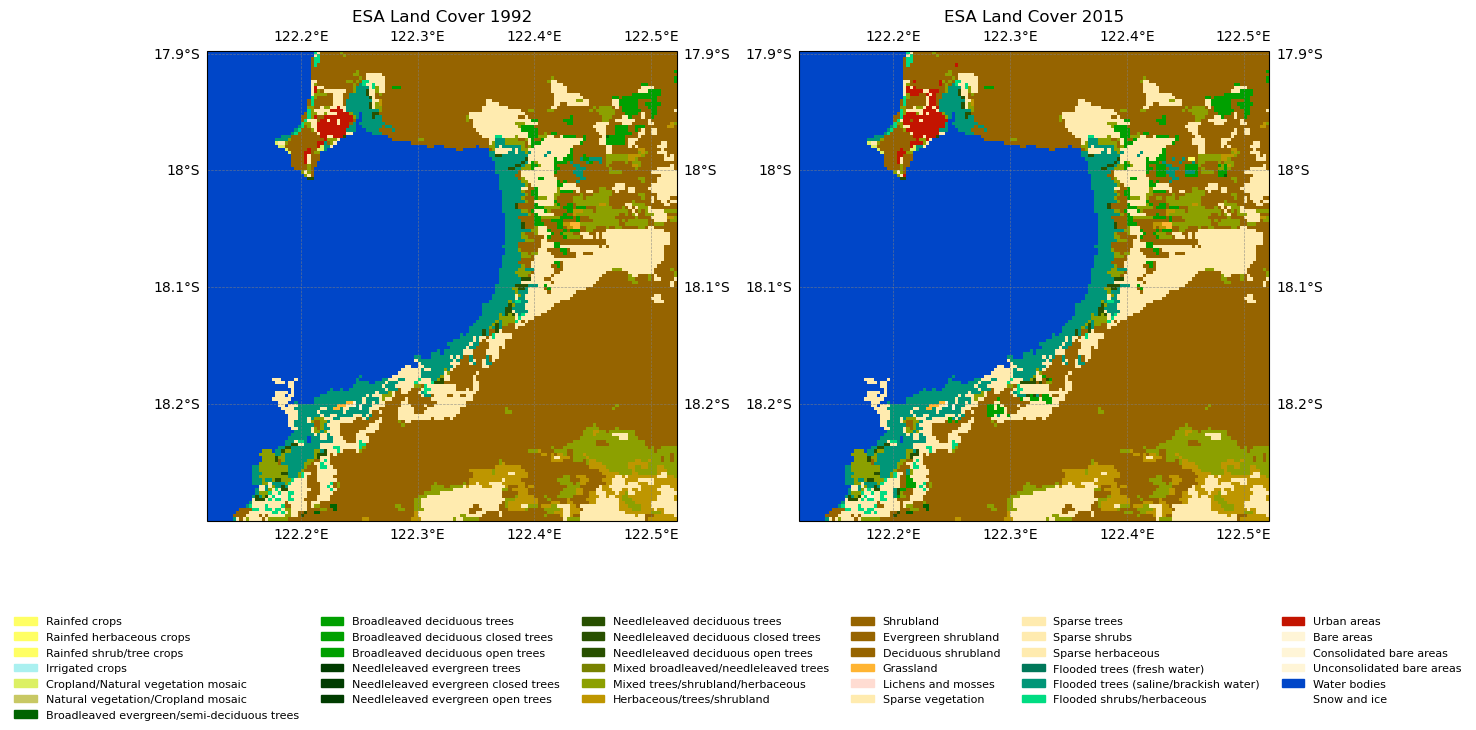

In [31]:
from livingearth_dictionary import esa_cci_lc_colours, esa_cci_lc_labels

start_year = int(start_date)
end_year = int(end_date)

year_range = range(start_year, end_year + 1)

# Only take first and last year
years_to_plot = [year_range[0], year_range[-1]]

class_ids = sorted(esa_cci_lc_labels.keys())
cmap = ListedColormap(esa_cci_lc_colours)
norm = BoundaryNorm(class_ids + [max(class_ids) + 1], ncolors=cmap.N)

# Create a figure with one column per selected year
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(years_to_plot),
    figsize=(6 * len(years_to_plot), 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Ensure axes is iterable
if len(years_to_plot) == 1:
    axes = [axes]

for ax, year in zip(axes, years_to_plot):
    print(f"Processing year {year}...")
    timestep = f"{year}-01-01"

    # Load land cover data
    lc = lc_sub["lccs_class"].sel(time=timestep, method="nearest").squeeze().compute()
    lat = lc["lat"]
    lon = lc["lon"]

    # Plot land cover
    ax.pcolormesh(lon, lat, lc.values, cmap=cmap, norm=norm, shading="auto")

    # Gridlines
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--")

    ax.set_title(f"ESA Land Cover {year}")

# Build a single legend for all subplots
legend_handles = [
    Patch(color=esa_cci_lc_colours[class_ids.index(cid)], label=esa_cci_lc_labels[cid])
    for cid in class_ids
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=8,
    frameon=False
)

# Adjust layout to leave space for legend
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [32]:
esa_cci_deconstruction = {
    10: 111, 11: 111, 12: 111, 20: 111, 30: 111 ,        # 111: Cultivated Terrestrial Vegetation (CTV)                       
    40: 112, 50: 112, 60: 112,                          # 112: Natural Terrestrial Vegetation (NTV)
    61: 112, 62: 112, 70: 112, 71: 112, 72: 112,
    80: 112, 81: 112, 82: 112, 90: 112, 100: 112, 110: 112,
    120: 112, 121: 112, 122: 112, 130: 112, 140: 112,
    150: 112, 151: 112, 152: 112, 153: 112,
    160: 124, 170: 124, 180: 124,                        # 124: Natural Aquatic Vegetation (NAV)
    190: 215,                                           # 215: Artificial Surfaces
    200: 216, 201: 216, 202: 216 ,                       # 216: Naturally bare surfaces
    210: 220, 220: 220                                  # 220: Water (artificial and natural)
}

da = lc_sub['lccs_class']

arr = da.data.compute() if hasattr(da.data, "compute") else da.values

# ------------------------------------------------------------
# Output raster
# ------------------------------------------------------------
esa_cci_deconstruction_data = np.zeros(arr.shape, dtype=np.int16)

# ------------------------------------------------------------
# Reclassify
# ------------------------------------------------------------
for k, v in esa_cci_deconstruction.items():
    esa_cci_deconstruction_data[arr == k] = v

# ------------------------------------------------------------
# Build DataArray
# ------------------------------------------------------------
esa_cci_deconstruction_data_da = xr.DataArray(
    esa_cci_deconstruction_data,
    coords=da.coords,
    dims=da.dims,
    name="Level 3"
).astype("int16")

# ------------------------------------------------------------
# Attach back
# ------------------------------------------------------------
lc_sub["Level 3"] = esa_cci_deconstruction_data_da

# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------
print(np.unique(esa_cci_deconstruction_data))

[111 112 124 215 216 220]


In [33]:
from livingearth_dictionary import level3_colours, level3_labels
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

classes = sorted(level3_labels.keys())

level3_cmap = ListedColormap([level3_colours[c] for c in classes])

level3_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=len(classes)
)

In [34]:
print(level3_colours)

{0: '#FFFFFF', 111: '#D1E133', 112: '#007A02', 123: '#4EEEE8', 124: '#02C077', 215: '#DA5C69', 216: '#F3AB69', 220: '#4D9FDC'}


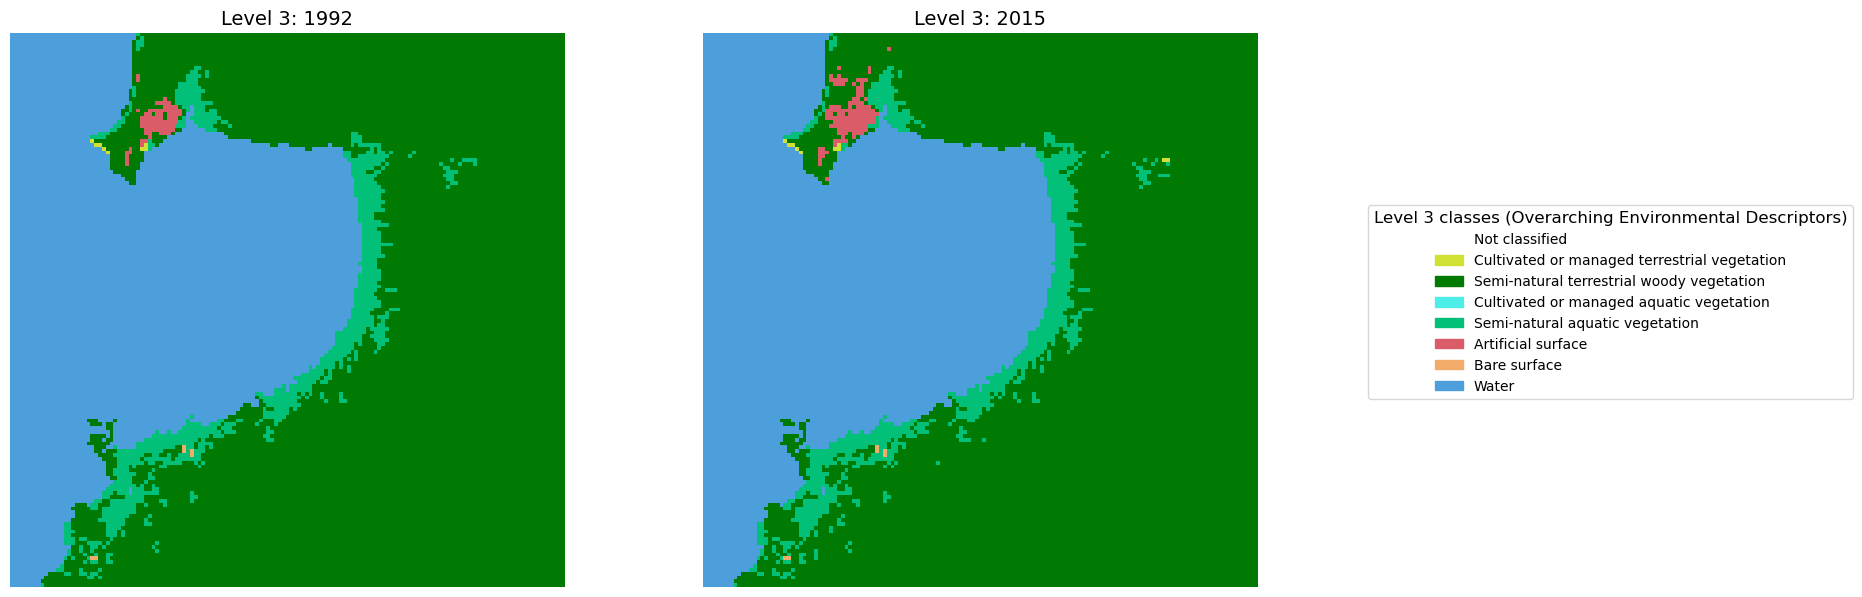

In [35]:
# Select data for start and end dates
da_start = lc_sub["Level 3"].sel(time=start_date).squeeze()
da_end   = lc_sub["Level 3"].sel(time=end_date).squeeze()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot start date
im0 = axes[0].imshow(
    da_start.values,
    cmap=level3_cmap,
    norm=level3_norm,
    interpolation="nearest",
    extent=[
        float(da_start.lon.min()),
        float(da_start.lon.max()),
        float(da_start.lat.min()),
        float(da_start.lat.max()),
    ],
    origin="upper"
)
axes[0].set_title(f"Level 3: {start_date}", fontsize=14)
axes[0].set_axis_off()

# Plot end date
im1 = axes[1].imshow(
    da_end.values,
    cmap=level3_cmap,
    norm=level3_norm,
    interpolation="nearest",
    extent=[
        float(da_end.lon.min()),
        float(da_end.lon.max()),
        float(da_end.lat.min()),
        float(da_end.lat.max()),
    ],
    origin="upper"
)
axes[1].set_title(f"Level 3: {end_date}", fontsize=14)
axes[1].set_axis_off()

# Build a single legend for all classes
patches = [
    Patch(color=level3_colours[code], label=level3_labels[code])
    for code in sorted(level3_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=10,
    title='Level 3 classes (Overarching Environmental Descriptors)',
    title_fontsize=12
)

plt.subplots_adjust(right=0.78, wspace=0.05)  # adjust space between plots and legend
plt.show()

## Recontruct lifeform

In [36]:
esa_cci_dlifeform = {
    10: 2, #"Rainfed crops",
    11: 2, #"Rainfed herbaceous crops",
    12: 1, #"Rainfed shrub/tree crops",
    20: 2, #"Irrigated crops",
    30: 2, #"Cropland/Natural vegetation mosaic",
    40: 2, #"Natural vegetation/Cropland mosaic",
    50: 1, #"Broadleaved evergreen/semi-deciduous trees",
    60: 1, #"Broadleaved deciduous trees",
    61: 1, #"Broadleaved deciduous closed trees",
    62: 1, #"Broadleaved deciduous open trees",
    70: 1, #"Needleleaved evergreen trees",
    71: 1, #"Needleleaved evergreen closed trees",
    72: 1, #"Needleleaved evergreen open trees",
    80: 1, #"Needleleaved deciduous trees",
    81: 1, #"Needleleaved deciduous closed trees",
    82: 1, #"Needleleaved deciduous open trees",
    90: 1, #"Mixed broadleaved/needleleaved trees",
    100: 1, #"Mixed trees/shrubland/herbaceous",
    110: 2, #"Herbaceous/trees/shrubland",
    120: 1, #"Shrubland",
    121: 1, #"Evergreen shrubland",
    122: 1, #"Deciduous shrubland",
    130: 2, #"Grassland",
    140: 2, #"Lichens and mosses",
    150: 2, #"Sparse vegetation",
    151: 1, #"Sparse trees",
    152: 1, #"Sparse shrubs",
    153: 2, #"Sparse herbaceous",
    160: 1, #"Flooded trees (fresh water)",
    170: 1, #"Flooded trees (saline/brackish water)",
    180: 1, #"Flooded shrubs/herbaceous",
    190: 0, #"Urban areas",
    200: 0, #"Bare areas",
    201: 0, #"Consolidated bare areas",
    202: 0, #"Unconsolidated bare areas",
    210: 0, #"Water bodies",
    220: 0, #"Snow and ice"
}

da = lc_sub['lccs_class']

arr = da.data.compute() if hasattr(da.data, "compute") else da.values

# ------------------------------------------------------------
# Output raster
# ------------------------------------------------------------
esa_cci_dlifeform_data = np.zeros(arr.shape, dtype=np.int16)

# ------------------------------------------------------------
# Reclassify
# ------------------------------------------------------------
for k, v in esa_cci_dlifeform.items():
    esa_cci_dlifeform_data[arr == k] = v

# ------------------------------------------------------------
# Build DataArray
# ------------------------------------------------------------
esa_cci_dlifeform_data_da = xr.DataArray(
    esa_cci_dlifeform_data,
    coords=da.coords,
    dims=da.dims,
    name="Lifeform"
).astype("int16")

# ------------------------------------------------------------
# Attach back
# ------------------------------------------------------------
lc_sub["Lifeform"] = esa_cci_dlifeform_data_da

# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------
print(np.unique(esa_cci_dlifeform_data))

[0 1 2]


In [37]:
from livingearth_dictionary import lifeform_colours, lifeform_labels
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

classes = sorted(lifeform_labels.keys())

lifeform_cmap = ListedColormap([lifeform_colours[c] for c in classes])

lifeform_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=len(classes)
)

In [38]:
print(lifeform_colours)

['#FFFFFF', '#21852C', '#A3CA54']


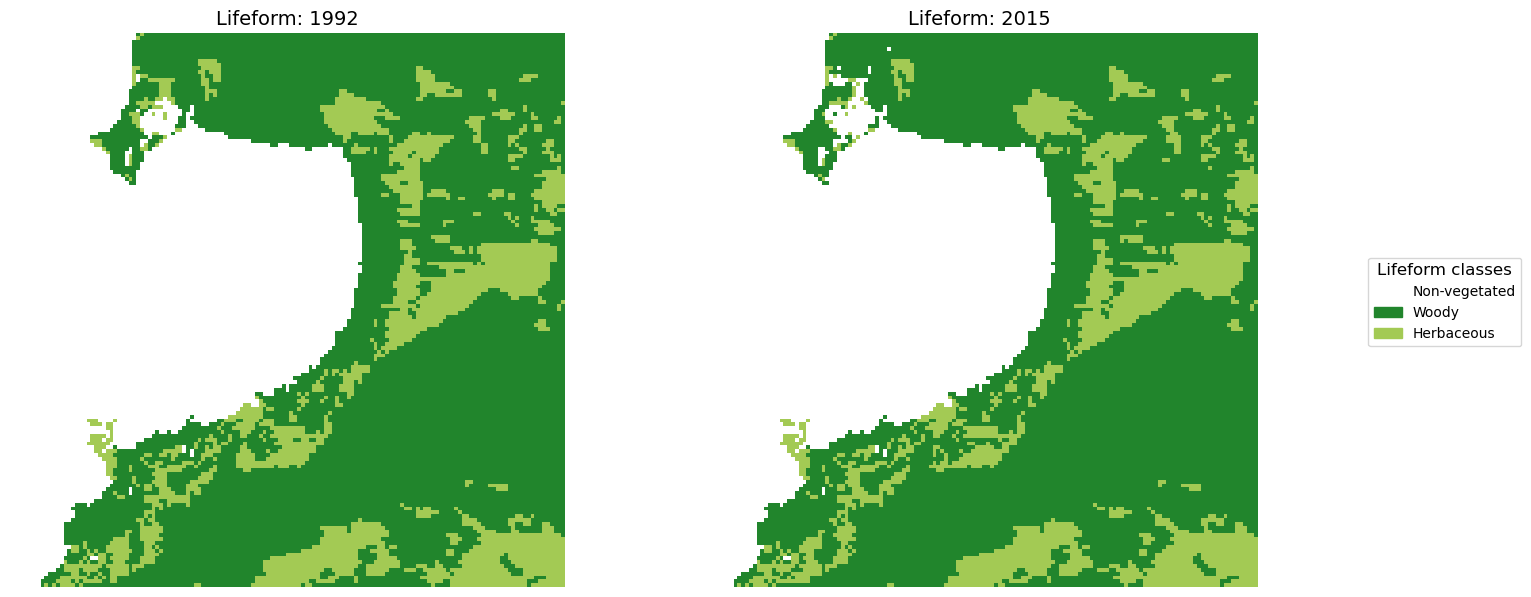

In [39]:
# Select data for start and end dates
da_start = lc_sub["Lifeform"].sel(time=start_date).squeeze()
da_end   = lc_sub["Lifeform"].sel(time=end_date).squeeze()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot start date
im0 = axes[0].imshow(
    da_start.values,
    cmap=lifeform_cmap,
    norm=lifeform_norm,
    interpolation="nearest",
    extent=[
        float(da_start.lon.min()),
        float(da_start.lon.max()),
        float(da_start.lat.min()),
        float(da_start.lat.max()),
    ],
    origin="upper"
)
axes[0].set_title(f"Lifeform: {start_date}", fontsize=14)
axes[0].set_axis_off()

# Plot end date
im1 = axes[1].imshow(
    da_end.values,
    cmap=lifeform_cmap,
    norm=lifeform_norm,
    interpolation="nearest",
    extent=[
        float(da_end.lon.min()),
        float(da_end.lon.max()),
        float(da_end.lat.min()),
        float(da_end.lat.max()),
    ],
    origin="upper"
)
axes[1].set_title(f"Lifeform: {end_date}", fontsize=14)
axes[1].set_axis_off()

# Build a single legend for all classes
patches = [
    Patch(color=lifeform_colours[code], label=lifeform_labels[code])
    for code in sorted(lifeform_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=10,
    title='Lifeform classes',
    title_fontsize=12
)

plt.subplots_adjust(right=0.78, wspace=0.05)  # adjust space between plots and legend
plt.show()

## Recontruct vegetation cover (forests)

In [40]:
esa_cci_dcover = {
    10: 10, #"Rainfed crops",
    11: 10, #"Rainfed herbaceous crops",
    12: 10, #"Rainfed shrub/tree crops",
    20: 10, #"Irrigated crops",
    30: 10, #"Cropland/Natural vegetation mosaic",
    40: 10, #"Natural vegetation/Cropland mosaic",
    50: 9, #"Broadleaved evergreen/semi-deciduous trees",
    60: 9, #"Broadleaved deciduous trees",
    61: 10, #"Broadleaved deciduous closed trees",
    62: 12, #"Broadleaved deciduous open trees",
    70: 9, #"Needleleaved evergreen trees",
    71: 10, #"Needleleaved evergreen closed trees",
    72: 12, #"Needleleaved evergreen open trees",
    80: 9, #"Needleleaved deciduous trees",
    81: 10, #"Needleleaved deciduous closed trees",
    82: 12, #"Needleleaved deciduous open trees",
    90: 0, #"Mixed broadleaved/needleleaved trees",
    100: 12, #"Mixed trees/shrubland/herbaceous",
    110: 12, #"Herbaceous/trees/shrubland",
    120: 13, #"Shrubland",
    121: 13, #"Evergreen shrubland",
    122: 13, #"Deciduous shrubland",
    130: 10, #"Grassland",
    140: 13, #"Lichens and mosses",
    150: 15, #"Sparse vegetation",
    151: 15, #"Sparse trees",
    152: 15, #"Sparse shrubs",
    153: 15, #"Sparse herbaceous",
    160: 10, #"Flooded trees (fresh water)",
    170: 10, #"Flooded trees (saline/brackish water)",
    180: 12, #"Flooded shrubs/herbaceous",
    190: 0, #"Urban areas",
    200: 0, #"Bare areas",
    201: 16, #"Consolidated bare areas",
    202: 16, #"Unconsolidated bare areas",
    210: 0, #"Water bodies",
    220: 0, #"Snow and ice"
}

da = lc_sub['lccs_class']

arr = da.data.compute() if hasattr(da.data, "compute") else da.values

# ------------------------------------------------------------
# Output raster
# ------------------------------------------------------------
esa_cci_dcover_data = np.zeros(arr.shape, dtype=np.int16)

# ------------------------------------------------------------
# Reclassify
# ------------------------------------------------------------
for k, v in esa_cci_dcover.items():
    esa_cci_dcover_data[arr == k] = v

# ------------------------------------------------------------
# Build DataArray
# ------------------------------------------------------------
esa_cci_dcover_data_da = xr.DataArray(
    esa_cci_dcover_data,
    coords=da.coords,
    dims=da.dims,
    name="Cover"
).astype("int16")

# ------------------------------------------------------------
# Attach back
# ------------------------------------------------------------
lc_sub["Cover"] = esa_cci_dcover_data_da

# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------
datavalues = (np.unique(esa_cci_dcover_data))
print(datavalues)

[ 0  9 10 12 13 15]


In [41]:
# Example: your dataset
from livingearth_dictionary import cover_colours, cover_labels


# --- Step 1: Find unique class values in your dataset ---
data_values = np.unique(esa_cci_dcover_data)

# --- Step 2: Build a dict mapping class ID -> color for classes present ---
cover_color_dict = {cls: cover_colours[cls] for cls in data_values if cls in cover_colours}

# --- Step 3: Sort class IDs present in the data ---
classes_present = sorted(cover_color_dict.keys())

# --- Step 4: Create a ListedColormap with only the colors for present classes ---
cover_cmap = ListedColormap([cover_color_dict[c] for c in classes_present])

# --- Step 5: Create a BoundaryNorm for these classes ---
cover_norm = BoundaryNorm(
    boundaries=classes_present + [classes_present[-1] + 1],
    ncolors=len(classes_present)
)


In [42]:
# Only use classes present in this subset
data_values = np.unique(esa_cci_dcover_data)
print("Values present:", data_values)

# Only keep colors for values present in the dataset
classes_present = sorted([v for v in data_values if v in cover_colours])
colors_present = [cover_colours[v] for v in classes_present]

# Create ListedColormap
cover_cmap = ListedColormap(colors_present)

# Create a BoundaryNorm that maps data values to colors
# Boundaries must be set such that each integer value is centered in a bin
boundaries = [v - 0.5 for v in classes_present] + [classes_present[-1] + 0.5]
cover_norm = BoundaryNorm(boundaries, ncolors=len(classes_present))

Values present: [ 0  9 10 12 13 15]


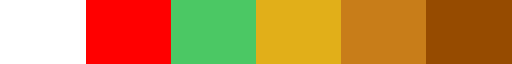

In [43]:
cover_cmap

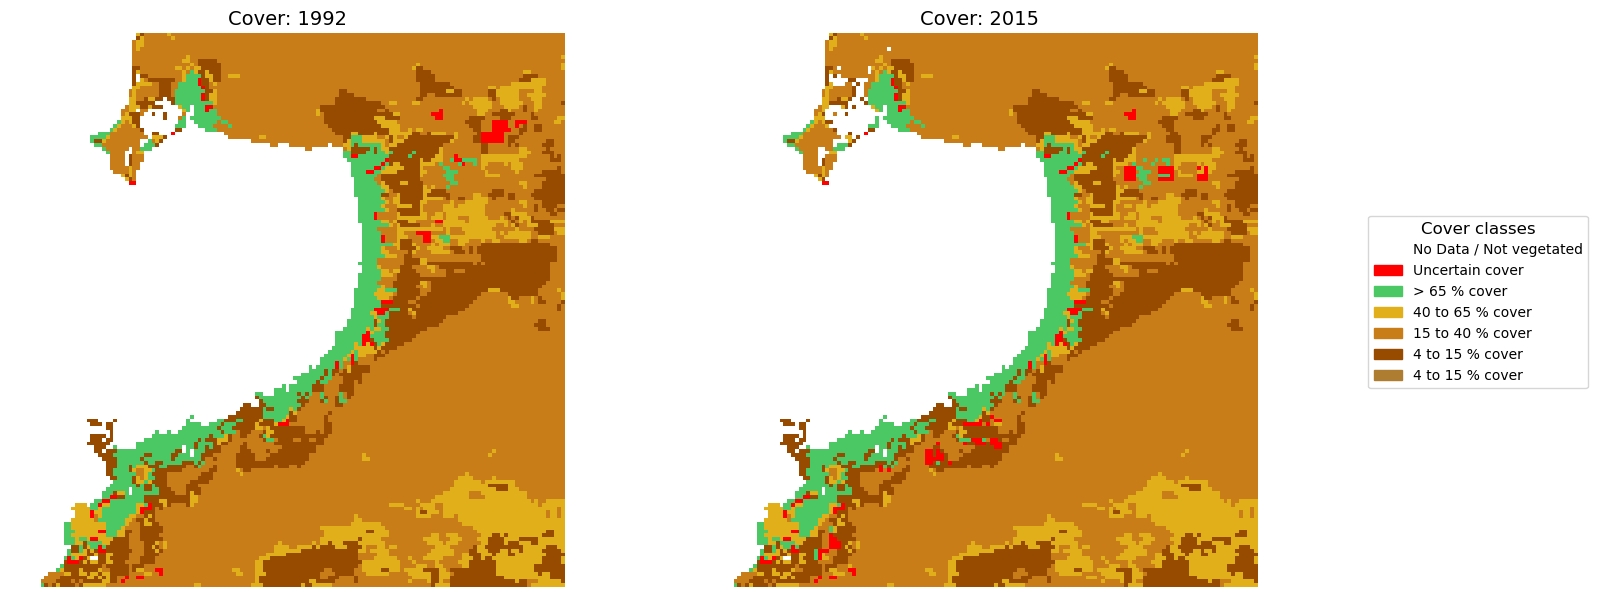

In [44]:
# Select data for start and end dates
da_start = lc_sub["Cover"].sel(time=start_date).squeeze()
da_end   = lc_sub["Cover"].sel(time=end_date).squeeze()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot start date
im0 = axes[0].imshow(
    da_start.values,
    cmap=cover_cmap,
    norm=cover_norm,
    interpolation="nearest",
    extent=[
        float(da_start.lon.min()),
        float(da_start.lon.max()),
        float(da_start.lat.min()),
        float(da_start.lat.max()),
    ],
    origin="upper"
)
axes[0].set_title(f"Cover: {start_date}", fontsize=14)
axes[0].set_axis_off()

# Plot end date
im1 = axes[1].imshow(
    da_end.values,
    cmap=cover_cmap,
    norm=cover_norm,
    interpolation="nearest",
    extent=[
        float(da_end.lon.min()),
        float(da_end.lon.max()),
        float(da_end.lat.min()),
        float(da_end.lat.max()),
    ],
    origin="upper"
)
axes[1].set_title(f"Cover: {end_date}", fontsize=14)
axes[1].set_axis_off()

# Build a single legend for all classes
patches = [
    Patch(color=cover_colours[code], label=cover_labels[code])
    for code in sorted(cover_labels.keys())
]

fig.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=True,
    fontsize=10,
    title='Cover classes',
    title_fontsize=12
)

plt.subplots_adjust(right=0.78, wspace=0.05)  # adjust space between plots and legend
plt.show()

In [45]:
unique_vals = np.unique(da_start)  # find unique values
print(unique_vals)                 # print them

[ 0  9 10 12 13 15]


## Observed change
The observed change considers conversions (i.e., changes in extent of the Level 3 classes) and modifications (i.e., the level 3 class remains the same but there are changes in categorical (e.g., lifeform) or continuous (e.g., water hydroperiod) environmental descriptors).

### Level 3 change maps 

The first step towards developing a globally relevant and standardized taxonomy and framework for consistently describing land cover change was to establish the transition matrix between observed broad land cover classes (i.e., OEDs).  This stage was developed (and is illustrated) using the FAO LCCS given the dichotomous and then hierarchical modular structure of this taxonomy.  Between-class transitions and within-class changes can be identified by comparing these OEDs (i.e., the FAO LCCS Level 3 classes; 8 in total) between any two time-separated periods (i.e., T1 and T2), leading to 64 potential change categories; 56 on the off-diagonals and 8 on the on-diagonals.  

In the following steps, you will compare the earliest and latest Level 3 layers in selected time-series.

In [46]:
unique_values = np.unique(lc_sub["Level 3"].sel(time=start_date, method='nearest').values)
print(unique_values)
unique_values = np.unique(lc_sub["Level 3"].sel(time=end_date, method='nearest').values)
print(unique_values)

[111 112 124 215 216 220]
[111 112 124 215 216 220]


## Gains in land cover

In [47]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_sub["Level 3"].sel(time=start_date, method='nearest').astype(np.int64).drop_vars("time")
end   = lc_sub["Level 3"].sel(time=end_date, method='nearest').astype(np.int64).drop_vars("time")
ignore_no_change = True
change_vals = (start * 1000 + end)  # 1000 to keep 6-digit codes intact
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([     0, 112124, 112215, 124111, 124112, 124215])

In [48]:
# #level3 = lc_sub["Level 3"].sel(time=start_date, method='nearest').drop_vars("time")

# obs_gain_l3_T1T2 = xr.DataArray(
#     data=change_vals,
#     lc_sub["Level 3"]
#     coords=level3.coords,
#     dims=level3.dims,
#     name="observed change",
#     attrs=level3.attrs,
#     fastpath=False,
# )

In [49]:
da_2d = lc_sub.isel(time=0)
obs_gain_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="observed change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [50]:
obs_gain_l3 = obs_gain_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_gain_l3_T1T2

In [51]:
obs_gain_l3.l3_T1T2
unique_vals = np.unique(obs_gain_l3.l3_T1T2.values)

print(unique_vals)

[     0 112124 112215 124111 124112 124215]


In [52]:
from livingearth_dictionary import level3_gainloss_colours, level3_gainloss_labels

# Sorted classes
classes = sorted(level3_gainloss_labels.keys())

# Map class IDs to colors
level3_gainloss_colours_dict = {cid: color for cid, color in zip(classes, level3_gainloss_colours)}

# Create colormap
level3_gainloss_cmap = ListedColormap([level3_gainloss_colours_dict[c] for c in classes])

# Create norm
level3_gainloss_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=level3_gainloss_cmap.N
)

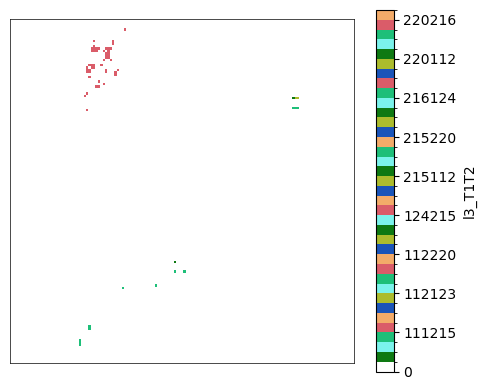

In [53]:
# --- Ensure dataset has CRS and reproject to EPSG:4326 ---
obs_gain_l3 = obs_gain_l3.rio.write_crs("EPSG:3577")

# Plot your reprojected data (square figure)
fig, ax = plt.subplots(figsize=(5, 4))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_gain_l3.l3_T1T2.plot(
    ax=ax,
    cmap=level3_gainloss_cmap,
    norm=level3_gainloss_norm,
    add_colorbar=True
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add black box around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

## Losses in land cover

In [54]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc_sub["Level 3"].sel(time=start_date, method='nearest').astype(np.int64).drop_vars("time")
end   = lc_sub["Level 3"].sel(time=end_date, method='nearest').astype(np.int64).drop_vars("time")
ignore_no_change = True
change_vals = (end * 1000 + start)  # 1000 to keep 6-digit codes intact
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([     0, 111124, 112124, 124112, 215112, 215124])

In [55]:
level3 = lc_sub["Level 3"].sel(time=start_date, method='nearest').drop_vars("time")
# Create a new Xarray.DataArray
obs_loss_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="observed gains",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [56]:
obs_loss_l3 = obs_loss_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_loss_l3_T1T2

In [57]:
obs_loss_l3.l3_T1T2
unique_vals = np.unique(obs_loss_l3.l3_T1T2.values)

print(unique_vals)

[     0 111124 112124 124112 215112 215124]


In [58]:
from livingearth_dictionary import level3_gainloss_colours, level3_gainloss_labels

# Sorted classes
classes = sorted(level3_gainloss_labels.keys())

# Map class IDs to colors
level3_gainloss_colours_dict = {cid: color for cid, color in zip(classes, level3_gainloss_colours)}

# Create colormap
level3_gainloss_cmap = ListedColormap([level3_gainloss_colours_dict[c] for c in classes])

# Create norm
level3_gainloss_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=level3_gainloss_cmap.N
)

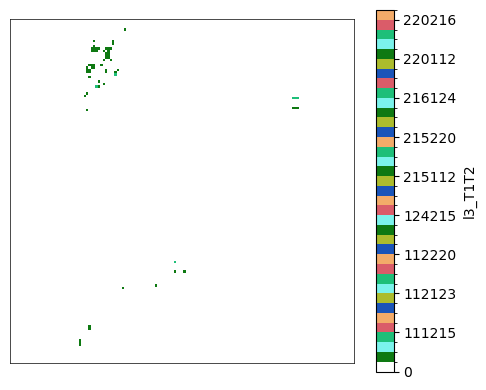

In [59]:
# --- Ensure dataset has CRS and reproject to EPSG:4326 ---
obs_loss_l3 = obs_loss_l3.rio.write_crs("EPSG:3577")

# Plot your reprojected data (square figure)
fig, ax = plt.subplots(figsize=(5, 4))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_loss_l3.l3_T1T2.plot(
    ax=ax,
    cmap=level3_gainloss_cmap,
    norm=level3_gainloss_norm,
    add_colorbar=True
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)


# Add black box around map
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

### NO CHANGE

In [60]:
start = lc_sub["Level 3"].sel(time=start_date, method='nearest').astype(np.int64)
end   = lc_sub["Level 3"].sel(time=end_date, method='nearest').astype(np.int64)
ignore_no_change = True
change_vals = (start * 1000 + end)  # 1000 to keep 6-digit codes intact
if ignore_no_change:
    change_vals = np.where(start != end, 0, change_vals)
display(np.unique(change_vals))

array([     0, 111111, 112112, 124124, 215215, 216216, 220220])

In [61]:
level3 = lc_sub["Level 3"].sel(time=start_date, method='nearest').drop_vars("time")
# Create a new Xarray.DataArray
obs_no_change_l3_T1T2 = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="no change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [62]:
obs_no_change_l3= obs_no_change_l3_T1T2.to_dataset(name="l3_T1T2")
del obs_no_change_l3_T1T2

In [63]:
obs_no_change_l3.l3_T1T2
unique_vals = np.unique(obs_no_change_l3.l3_T1T2.values)

print(unique_vals)

[     0 111111 112112 124124 215215 216216 220220]


In [64]:
# Define a colour scheme for the Level 3 no change
LEVEL3_NOCHANGE = {
    0: (255, 255, 255, 255, "Change"),
    111111: (172, 188, 45, 255, " "),
    112112: (14, 121, 18, 255, " "),
    123123: (0, 255, 255, 255, " "),
    124124: (30, 191, 121, 255, " "),
    215215: (218, 92, 105, 255, " "),
    216216: (243, 171, 105, 255, " "),
    220220: (77, 159, 220, 255, " ")}

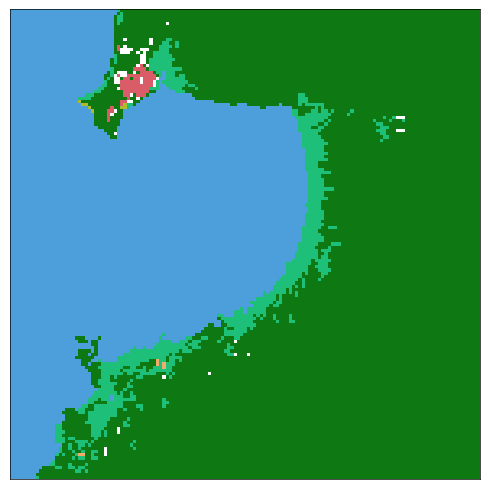

In [65]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Extract codes and colors
codes = list(LEVEL3_NOCHANGE.keys())
rgba_colors = [(r/255, g/255, b/255, a/255) for (r, g, b, a, _) in LEVEL3_NOCHANGE.values()]

# Make a ListedColormap
cmap = mcolors.ListedColormap(rgba_colors, name='Level3')

# Make boundaries centered on your codes
codes_sorted = sorted(codes)
bounds = [c - 0.5 for c in codes_sorted] + [codes_sorted[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Ensure dataset has CRS but DO NOT reproject ---
obs_no_change_l3 = obs_no_change_l3.rio.write_crs("EPSG:3577")

# Plot using native EPSG:3577 coordinates (square figure)
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
main_pos = ax.get_position()

c = obs_no_change_l3.l3_T1T2.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

# Remove tick marks and coordinate labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    " ",
    fontsize=20,
    ha="left",
    va="bottom"
)

# Add thin black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)

# Title (currently blank to match your example)
ax.set_title("", fontsize=16)

plt.tight_layout()
plt.show()

### Lifeform changes
The following generates maps of change by concatenating the values for lifeform identified in each of the two time-steps (e.g., 1988 and 2024), noting that some areas can go from no vegetation to woody or herbaceous (i.e., 01 or 02), from these categories to no vegetation (i.e., 10 or 20) or remain as non-vegetated (0 to 0).  The lifeform can remain the same (i.e., 11 or 22) or change (i.e. 12 or 21).  This is summarised in the table below.

| Value |  LCCS Description         |
|-------|-------------------------|
| 11     |Remains as woody|
| 22     |Remains as herbaceous |
| 12     |Woody to herbaceous|
| 21     |Herbaceous to woody|
| 01     |Not vegetated to woody|
| 02     |Not vegetated to herbaceous |
| 10     |Woody to not vegetated|
| 20     |Herbaceous to not vegetated |

The following generates maps of these modifications, which represent a change in type.

In [66]:
lc_sub = lc_sub.rename({v: v.strip() for v in lc_sub.data_vars})
start = lc_sub["Lifeform"].sel(time=start_date, method='nearest').astype(np.int8)
end   = lc_sub["Lifeform"].sel(time=end_date, method='nearest').astype(np.int8)
ignore_no_change = False
change_vals = ((start * 10) + end)
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([ 0, 10, 11, 12, 20, 21, 22], dtype=int8)

In [67]:
print(list(lc_sub.data_vars))

['change_count', 'current_pixel_state', 'lccs_class', 'observation_count', 'processed_flag', 'Level 3', 'Lifeform', 'Cover']


In [68]:
obs_change_lf_modification = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="lifeform change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [69]:
from livingearth_dictionary import lifeform_change_colours, lifeform_change_labels
classes = sorted(lifeform_change_labels.keys())
lifeform_change_colours_dict = {cid: color for cid, color in zip(classes, lifeform_change_colours)}
lifeform_change_cmap = ListedColormap([lifeform_change_colours_dict[c] for c in classes])
lifeform_change_norm = BoundaryNorm(
    boundaries=classes + [classes[-1] + 1],
    ncolors=lifeform_change_cmap.N
)

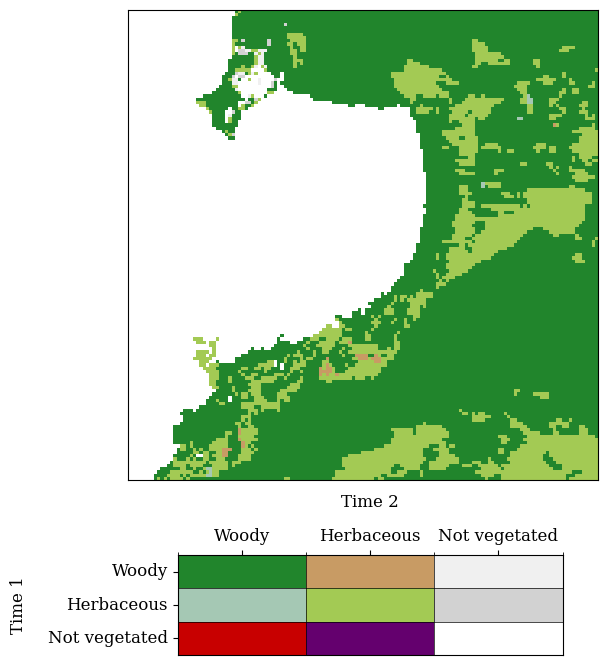

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

# -----------------------------
# Font settings
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times", "DejaVu Serif"]

# -----------------------------
# Classes for the legend (Time 1 vs Time 2)
# -----------------------------
classes = ("Not vegetated", "Herbaceous", "Woody")
n_classes = len(classes)

# -----------------------------
# Map row,col in 3x3 legend to lifeform_change class IDs
# -----------------------------
code_map = {
    (0,0): 11, (0,1): 21, (0,2): 20,
    (1,0): 12, (1,1): 22, (1,2): 10,
    (2,0): 1,  (2,1): 2,  (2,2): 0,
}

# -----------------------------
# Convert hex colors to RGB floats
# -----------------------------
lifeform_change_colors_rgb = [to_rgb(c) for c in lifeform_change_colours]

# Create colormap and norm
lifeform_change_cmap = ListedColormap(lifeform_change_colors_rgb)
lifeform_classes = sorted(lifeform_change_labels.keys())
lifeform_change_norm = BoundaryNorm(
    boundaries=lifeform_classes + [lifeform_classes[-1]+1],
    ncolors=lifeform_change_cmap.N
)

# Build mapping from class ID → colormap index
code_to_cmap_idx = {cid: i for i, cid in enumerate(lifeform_classes)}

# -----------------------------
# Build legend image (3x3)
# -----------------------------
legend_img = np.zeros((n_classes, n_classes, 3))
for i in range(n_classes):
    for j in range(n_classes):
        code = code_map[(i,j)]
        idx = code_to_cmap_idx[code]
        rgb = np.array(lifeform_change_cmap.colors[idx])  # RGB floats
        legend_img[i, j] = rgb

# -----------------------------
# Main figure: LIFEFORM change map
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    obs_change_lf_modification.values,  # Your DataArray of lifeform change
    cmap=lifeform_change_cmap,
    norm=lifeform_change_norm
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("", fontsize=16)

main_pos = ax.get_position()

# Optional figure label
fig.text(
    main_pos.x0,
    main_pos.y1 + 0.02,
    "",
    fontsize=20,
    ha="left",
    va="bottom"
)

# -----------------------------
# Legend axis below map
# -----------------------------
scale_factor = 0.8
legend_height = 0.25 * scale_factor
legend_spacing = 0.08
legend_bottom = main_pos.y0 - legend_height - legend_spacing - 0.15

legend_ax = fig.add_axes([
    main_pos.x0,
    legend_bottom,
    main_pos.width,
    legend_height
])

# Display legend image
legend_ax.imshow(
    legend_img,
    aspect='auto',
    extent=[0, n_classes, 0, n_classes * scale_factor]
)

# Tick positions
tick_pos = np.arange(n_classes) + 0.5
legend_ax.set_xticks(tick_pos)
legend_ax.set_yticks((np.arange(n_classes) + 0.5) * scale_factor)

# Legend axis labels
legend_ax.xaxis.set_label_position('top')
legend_ax.xaxis.tick_top()
legend_ax.set_xticklabels(classes[::-1], rotation=0, ha="center", fontsize=12)
legend_ax.set_yticklabels(classes, rotation=0, va="center", fontsize=12)

# Axis labels with padding
legend_ax.set_xlabel("Time 2", fontsize=12, labelpad=15)
legend_ax.set_ylabel("Time 1", fontsize=12, labelpad=15)

# Minor grid lines
legend_ax.set_xticks(np.arange(n_classes+1), minor=True)
legend_ax.set_yticks(np.arange(n_classes+1) * scale_factor, minor=True)
legend_ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
legend_ax.tick_params(which="minor", bottom=False, left=False)

plt.show()

In [71]:
start = lc_sub["Cover"].sel(time=start_date, method='nearest').astype(np.int64)
end   = lc_sub["Cover"].sel(time=end_date, method='nearest').astype(np.int64)
ignore_no_change = False
change_vals = (start * 100) + end
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)
display(np.unique(change_vals))

array([   0,  909,  912,  913,  915, 1000, 1010, 1013, 1200, 1209, 1212,
       1215, 1300, 1309, 1310, 1312, 1313, 1500, 1509, 1510, 1512, 1515])

In [76]:
obs_change_vcov_modification = xr.DataArray(
    data=change_vals,
    coords=da_2d.coords,
    dims=da_2d.dims,
    name="cover change",
    attrs=da_2d.attrs,
    fastpath=False,
)

In [77]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from livingearth_dictionary import cover_change_colours, cover_change_labels

# Use the codes in the order they appear in your colour list
# (matches your manual ordering in livingearth_dictionary)
codes_ordered = list(cover_change_labels.keys())

# Build colormap using the same order
cover_change_cmap = ListedColormap([cover_change_colours[codes_ordered.index(c)] for c in codes_ordered])

# Create BoundaryNorm so each code maps correctly to a color
cover_change_norm = BoundaryNorm(
    boundaries=codes_ordered + [codes_ordered[-1] + 1],
    ncolors=len(codes_ordered)
)

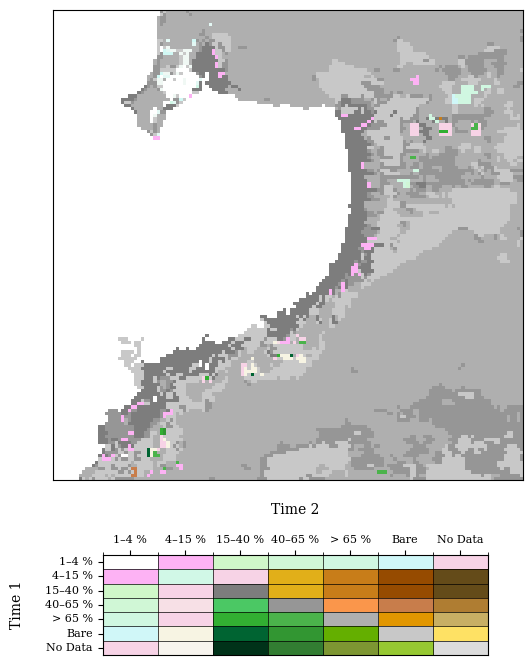

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

# -----------------------------
# Classes for legend (Time 1 vs Time 2)
# -----------------------------
classes = ["No Data", "Bare", "> 65 %", "40–65 %", "15–40 %", "4–15 %", "1–4 %"]
n_classes = len(classes)

# -----------------------------
# Map row,col in legend to cover_change IDs
# -----------------------------
code_map = {
    # Time 1: No Data
    (0,0):0,      (0,1):900,  (0,2):910,  (0,3):912,  (0,4):913,  (0,5):915,  (0,6):916,
    # Time 1: Bare
    (1,0):900,    (1,1):1000, (1,2):1009, (1,3):1012, (1,4):1013, (1,5):1015, (1,6):1016,
    # Time 1: >65 %
    (2,0):910,    (2,1):1009, (2,2):1010, (2,3):1012, (2,4):1013, (2,5):1015, (2,6):1016,
    # Time 1: 40–65 %
    (3,0):912,    (3,1):1209, (3,2):1210, (3,3):1212, (3,4):1213, (3,5):1215, (3,6):1216,
    # Time 1: 15–40 %
    (4,0):913,    (4,1):1309, (4,2):1310, (4,3):1312, (4,4):1313, (4,5):1315, (4,6):1316,
    # Time 1: 4–15 %
    (5,0):915,    (5,1):1509, (5,2):1510, (5,3):1512, (5,4):1513, (5,5):1515, (5,6):1516,
    # Time 1: 1–4 %
    (6,0):916,    (6,1):1609, (6,2):1610, (6,3):1612, (6,4):1613, (6,5):1615, (6,6):1616,
}

# -----------------------------
# Convert hex colors to RGB
# -----------------------------
cover_change_colors_rgb = [to_rgb(c) for c in cover_change_colours]

# -----------------------------
# Build mapping from class ID → colormap index
# This ensures KeyError cannot occur
# -----------------------------
cover_classes = list(cover_change_labels.keys())  # preserve exact order
code_to_cmap_idx = {cid: idx for idx, cid in enumerate(cover_classes)}

# Create colormap and norm
cover_change_cmap = ListedColormap(cover_change_colors_rgb)
cover_change_norm = BoundaryNorm(
    boundaries=np.array(cover_classes + [cover_classes[-1]+1]),
    ncolors=cover_change_cmap.N
)

# -----------------------------
# Build legend image
# -----------------------------
legend_img = np.zeros((n_classes, n_classes, 3))
for i in range(n_classes):
    for j in range(n_classes):
        code = code_map[(i,j)]
        idx = code_to_cmap_idx[code]  # now always safe
        legend_img[i,j] = cover_change_colors_rgb[idx]

# -----------------------------
# Plot main map
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    obs_change_vcov_modification.values,
    cmap=cover_change_cmap,
    norm=cover_change_norm
)
ax.set_xticks([])
ax.set_yticks([])

# Legend axis
# -----------------------------
main_pos = ax.get_position()
scale_factor = 0.8
legend_height = 0.25 * scale_factor
legend_spacing = 0.08
legend_bottom = main_pos.y0 - legend_height - legend_spacing - 0.15

legend_ax = fig.add_axes([
    main_pos.x0,
    legend_bottom,
    main_pos.width,
    legend_height
])

legend_ax.imshow(
    legend_img,
    aspect='auto',
    extent=[0, n_classes, 0, n_classes * scale_factor]
)

tick_pos = np.arange(n_classes) + 0.5
legend_ax.set_xticks(tick_pos)
legend_ax.set_yticks((np.arange(n_classes)+0.5)*scale_factor)

legend_ax.xaxis.set_label_position('top')
legend_ax.xaxis.tick_top()
legend_ax.set_xticklabels(classes[::-1], rotation=0, ha="center", fontsize=8)
legend_ax.set_yticklabels(classes, rotation=0, va="center", fontsize=8)

legend_ax.set_xlabel("Time 2", fontsize=10, labelpad=15)
legend_ax.set_ylabel("Time 1", fontsize=10, labelpad=15)

legend_ax.set_xticks(np.arange(n_classes+1), minor=True)
legend_ax.set_yticks(np.arange(n_classes+1)*scale_factor, minor=True)
legend_ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
legend_ax.tick_params(which="minor", bottom=False, left=False)

plt.show()

## The Global Change Taxonomy and Evidence-Based Change Framework
### Evidence for impacts
Evidence for different impacts is gathered through temporal comparison (e.g., days, decades apart) of land cover classes constructed and described from Environmental Descriptors (EDs; state indicators) with pre-defined measurement units (e.g., m, %) or categories (e.g., species type) and, more specifically, their concatenated codes (e.g., 12 indicating a change from a woody (1) to a herbaceous (2) lifeform. 

For the 77 impacts listed in the Global Change Taxonomy, this evidence has been reviewed and collated within the file ***Impacts and pressures.xlsx*** located within the directory ***gct***.  

### Evidence for pressures
Evidence for abiotic, biotic or human-induced pressures can come from a range of sources.    

<img align="centre" src="./illustrations/EvidencePressures.jpg">

For the 144 impacts, evidence can come from a range of sources and the file ***Impacts and pressures.xlsx*** can be modified based on what is available.  Normally, a pressure (such as a fire) is indicated by its presence (e.g. 1) or otherwise (0).

The following cell allows you to select one of the 77 impacts and associates this selection with a range of pressures that may be causative. 

In [79]:
# ==========================================================
# IMPORTS
# ==========================================================
import geopandas as gpd
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.patches import Patch

from IPython.display import (
    display,
    HTML,
    clear_output
)

# Load excel file

file_path = 'Impacts and pressures.xlsx'

df = pd.read_excel(
    file_path,
    sheet_name='Australia'
)

df['Impact_ID'] = (
    df['Impact_ID']
    .fillna(0)
    .astype(int)
)

df['Pressure_ID'] = (
    df['Pressure_ID']
    .fillna(0)
    .astype(int)
)

# Create look up for impacts

impact_to_pressures = df.groupby(
    ['Impacts', 'Impact_ID']
)[['Pressures', 'Pressure_ID']].apply(
    lambda x: [
        f"{row['Pressures']} ({row['Pressure_ID']})"
        for _, row in x.iterrows()
    ]
).to_dict()

# Ensure correct legend colours for impacts

from matplotlib.colors import ListedColormap, BoundaryNorm
from livingearth_dictionary import impact_colours, impact_labels

# Use the codes in the order they appear in your colour list
# (matches your manual ordering in livingearth_dictionary)
codes_ordered = list(impact_labels.keys())

# Build colormap using the same order
impact_cmap = ListedColormap([impact_colours[codes_ordered.index(c)] for c in codes_ordered])

# Create BoundaryNorm so each code maps correctly to a color
impact_norm = BoundaryNorm(
    boundaries=codes_ordered + [codes_ordered[-1] + 1],
    ncolors=len(codes_ordered)
)

# Extract values 

def extract_values(row, prefix):
    cols = [
        c for c in row.index
        if c.startswith(prefix)
    ]
    values = []

    for c in cols:
        val = row[c]
        if pd.isna(val):
            continue
        try:
            val = str(val).strip()
            if val == "" or val == "nan":
                continue
            values.append(
                int(float(val))
            )
        except:
            continue
    return values

# Build rule

def build_rule_from_row(row):
    mod_values  = extract_values(row, 'Mod')
    con_values  = extract_values(row, 'Con')
    lf_values   = extract_values(row, 'Lf')
    vcov_values = extract_values(row, 'Cov')

    def rule():
        base = xr.ones_like(
            obs_change_vcov_modification,
            dtype=bool
        )

# Level 3 (separation of modifications and conversions)

        mod_condition = (
            obs_no_change_l3.l3_T1T2.isin(mod_values)
            if mod_values else None
        )

        con_condition = (
            obs_gain_l3.l3_T1T2.isin(con_values)
            if con_values else None
        )

        if mod_condition is not None and con_condition is not None:
            level3_condition = (
                mod_condition |
                con_condition
            )
        elif mod_condition is not None:
            level3_condition = mod_condition
        elif con_condition is not None:
            level3_condition = con_condition
        else:
            level3_condition = base

# Lifeform
        lf_condition = (
            obs_change_lf_modification.isin(lf_values).astype(int)
            if lf_values else base
        )

# Vegetation cover
        vcov_condition = (
            obs_change_vcov_modification.isin(vcov_values).astype(int)
            if vcov_values else base
        )

# Final evidence inputs
        condition = (
            level3_condition &
            lf_condition &
            vcov_condition
        )
        return condition
    return rule

# Build rules

impact_rules = {}

for impact_id in df['Impact_ID'].unique():
    row = df[
        df['Impact_ID'] == impact_id
    ].iloc[0]

    impact_rules[impact_id] = (
        build_rule_from_row(row)
    )

# Create impact layer

def create_impact_layer(
    impact_id,
    pressure_id,
    condition,
    coords_source,
    name
):

    data = np.where(
        condition,
        impact_id,
        0
    )

    return xr.DataArray(
        data=data,
        coords=coords_source.coords,
        dims=coords_source.dims,
        name=name,
        attrs={
            "Impact_ID": impact_id,
            "Pressure_ID": pressure_id
        }
    ).to_dataset(name=name)

# Create dynamic legend

def create_selected_legend(selected_impacts):
    legend_handles = []

    # Build lookup from your existing dictionaries
    impact_lookup = {}

    for impact_id, label in impact_labels.items():
        colour = impact_colours[impact_id]
        impact_lookup[impact_id] = (colour, label)

    for impact_name, impact_id in selected_impacts:
        if impact_id not in impact_lookup:
            continue

        colour, label = impact_lookup[impact_id]

        patch = Patch(
            facecolor=colour,
            edgecolor='black',
            label=f"{impact_id}: {label}"
        )

        legend_handles.append(patch)

    return legend_handles

# Generate checkboxes

impact_checkboxes = {}

for impact_name, impact_id in impact_to_pressures.keys():
    label = f"{impact_name} ({impact_id})"
    impact_checkboxes[label] = widgets.Checkbox(
        value=False,
        description=label,
        indent=False,
        layout=widgets.Layout(width='700px')
    )

# Allow selection of all
select_all = widgets.Checkbox(
    value=False,
    description='Select All'
)

def toggle_all(change):
    for cb in impact_checkboxes.values():
        cb.value = change['new']

select_all.observe(
    toggle_all,
    names='value'
)

# Buttons

run_button = widgets.Button(
    description='Run Selected Impacts',
    button_style='success'
)

sum_button = widgets.Button(
    description='Create Summed Impacts',
    button_style='info'
)

output = widgets.Output()

# Run individual impacts

def run(button):
    with output:
        clear_output()
        selected = [
            cb.description
            for cb in impact_checkboxes.values()
            if cb.value
        ]

        if not selected:
            print("No impacts selected")
            return

        results = []

        for impact_text in selected:
            impact_name, impact_id = impact_text.rsplit(
                ' (',
                1
            )

            impact_id = int(
                impact_id.rstrip(')')
            )

            print(f"Running {impact_name}")
            rule = impact_rules[impact_id]
            condition = rule()
            ds = create_impact_layer(
                impact_id=impact_id,
                pressure_id=0,
                condition=condition,
                coords_source=obs_change_vcov_modification,
                name=impact_name.replace(" ", "_")
            )

            globals()[
                impact_name.replace(" ", "_")
            ] = ds

            results.append(
                (impact_name, ds)
            )

# Generate separate plots for all impacts

        n = len(results)
        cols = 3
        rows = int(
            np.ceil(n / cols)
        )

        fig, axes = plt.subplots(
            rows,
            cols,
            figsize=(6 * cols, 6 * rows)
        )
        axes = np.array(axes).reshape(-1)
        cmap = impact_cmap
        norm = impact_norm 

        for ax, (impact_name, ds) in zip(
            axes,
            results
        ):
            var = list(ds.data_vars)[0]
            da = ds[var]
            ax.imshow(
                da.values,
                cmap = impact_cmap,
                norm = impact_norm 
            )
            ax.set_title(
                impact_name
            )
            ax.axis("off")

        for ax in axes[len(results):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

# Sum impacts

def run_sum(button):
    with output:
        clear_output()
        selected = [
            cb.description
            for cb in impact_checkboxes.values()
            if cb.value
        ]

        if not selected:
            print("No impacts selected")
            return

        arrays = []
        selected_legend = []
        for impact_text in selected:
            impact_name, impact_id = impact_text.rsplit(
                ' (',
                1
            )
            impact_id = int(
                impact_id.rstrip(')')
            )
            var_name = impact_name.replace(
                " ",
                "_"
            )
            if var_name not in globals():

                print(
                    f"{var_name} not generated"
                )
                continue
            ds = globals()[var_name]
            data_var = list(ds.data_vars)[0]
            da = ds[data_var]
            arrays.append(da)

            selected_legend.append(
                (
                    impact_name,
                    impact_id
                )
            )

        if len(arrays) == 0:
            print("No arrays found")
            return

# Align

        aligned = xr.align(
            *arrays,
            join="exact"
        )

# Sum

        total = sum(aligned)
        total.name = "Impact_Sum"

# Create dataset

        Impacts = total.to_dataset(
            name="Sum"
        )

        for name, da in zip(
            [x[0] for x in selected_legend],
            aligned
        ):

            Impacts[
                name.replace(" ", "_")
            ] = da

        globals()["Impacts"] = Impacts

# Plot
 
        fig, ax = plt.subplots(
            figsize=(6, 5)
        )
        cmap = impact_cmap
        norm = impact_norm


        # If coords exist
        if 'x' in total.coords and 'y' in total.coords:
            xmin = float(total.coords['x'].min())
            xmax = float(total.coords['x'].max())
            ymin = float(total.coords['y'].min())
            ymax = float(total.coords['y'].max())
        else:
        # fallback for unnamed coordinates
            rows, cols = total.shape
            xmin, xmax = 0, cols
            ymin, ymax = 0, rows

# Generate a map of the combined impacts

        ax.imshow(
            total.values,
            cmap=cmap,
            norm=norm,
            extent=[xmin, xmax, ymin, ymax],
            origin='upper'
        )

        ax.set_title(
            "Summed Impacts",
            fontsize=18
        )

        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_color("black")

# Create a dynamic legend

        legend_handles = create_selected_legend(
            selected_legend
        )

        fig.legend(
            handles=legend_handles,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=9,
            title='Selected Impacts',
            title_fontsize=11,
            frameon=True
        )

        plt.tight_layout()
        plt.show()

# Display impacts
        display(Impacts)
# Button events
run_button.on_click(run)
sum_button.on_click(run_sum)

# Generate checkboxes
impact_checkboxes = {}

for impact_name, impact_id in impact_to_pressures.keys():
    label = f"{impact_name} ({impact_id})"
    impact_checkboxes[label] = widgets.Checkbox(
        value=False,
        description=label,
        indent=False,
        layout=widgets.Layout(width='700px')
    )

# "Select All" checkbox
select_all = widgets.Checkbox(
    value=False,
    description='Select All',
    indent=False,
    layout=widgets.Layout(width='200px')
)

def toggle_all(change):
    for cb in impact_checkboxes.values():
        cb.value = change['new']

select_all.observe(toggle_all, names='value')

# Layout in 3 columns
checkbox_list = list(impact_checkboxes.values())
n = len(checkbox_list)
col_size = int(np.ceil(n / 3))

col1 = widgets.VBox(checkbox_list[0:col_size])
col2 = widgets.VBox(checkbox_list[col_size:2*col_size])
col3 = widgets.VBox(checkbox_list[2*col_size:])

checkbox_container = widgets.HBox([col1, col2, col3])

# Display interface
display(widgets.VBox([
    widgets.HTML("<h2>Select Impacts</h2>"),
    select_all,
    widgets.HTML("<hr>"),
    checkbox_container,
    widgets.HTML("<br>"),
    widgets.HBox([
        run_button,
        sum_button
    ]),
    widgets.HTML("<hr>"),
    output
]))

FileNotFoundError: [Errno 2] No such file or directory: 'Impacts and pressures.xlsx'

## Bringing in pressure datasets

### 🛰️ CCI FIRE
We will use the data products from the [CCI Fire](https://climate.esa.int/en/projects/fire/) project and look at the burned areas. Details about the dataset can be found on the project website and the provided [Product User Guide](https://climate.esa.int/media/documents/Fire_cci_D4.2.1_PUG-MODIS_v1.1.pdf).  

With the command `list_ecv_datasets('Fire')`, we can call a list of all available CCI Fire datasets which can be loaded via the esa-climate-toolbox.

Before loading the data, we can inspect its structure and look at the attributes, data variables, dimensions, etc. by using the toolbox command `describe_data`.

In [84]:
list_ecv_datasets('Fire')

[('esacci.FIRE.mon.L4.BA.MODIS.Terra.MODIS_TERRA.v5-1.grid', 'esa-cci'),
 ('esacci.FIRE.mon.L4.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.grid',
  'esa-cci'),
 ('esacci.FIRE.mon.L4.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.v1-1.grid',
  'esa-cci'),
 ('esacci.FIRE.mon.L4.BA.multi-sensor.multi-platform.SYN.v1-1.grid',
  'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel', 'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.pixel',
  'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.v1-1.pixel',
  'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.multi-sensor.multi-platform.SYN.v1-1.pixel',
  'esa-cci'),
 ('ESACCI-L4_FIRE-BA-MODIS-2001-2022-fv5.1.zarr', 'esa-cci-zarr')]

We will use the MODIS_TERRA dataset as it contains pixel data in a high resolution which suits our purpose very well. 

As first step, we have a look at the potential opener parameters.

In [87]:
fire_dataset = "esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel"
cci_store = new_data_store('esa-cci')
cci_store.get_open_data_params_schema(fire_dataset)

In [88]:
fire_dataset = "esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel"

In [89]:
cci_store = new_data_store('esa-cci')
cci_store.get_open_data_params_schema(fire_dataset)

🔍 What do we learn from the details?

The temporal resolution of the burned area data is monthly and covers 2001 - 2022. The spatial resolution is 0.0022° which corresponds to a pixel size of approximately 250 m x 250 m on the Iberian Peninsula. The unit of the burned area is m<sup>2</sup>.


From the [Product User Guide](https://climate.esa.int/media/documents/Fire_cci_D4.2.1_PUG-MODIS_v1.1.pdf) we can get the information on the Areas. The table is also shown here for your convenince. 
For the Iberian Wildfires, we need the Area 3. 

| Area | Name | Upper Left | Lower Right |
|------|------|------------|-------------|
| 1 | North America | 180°W, 83°N | 50°W, 19°N |
| 2 | South America | 105°W, 19°N | 34°W, 57°S |
| 3 | Europe – North Africa | 26°W, 83°N | 53°E, 25°N |
| 4 | Asia | 53°E, 83°N | 180°E, 0°N |
| 5 | Sub-Saharan Africa | 26°W, 25°N | 53°E, 0°N |
| 6 | Australia & New Zealand | 95°E, 40°S | 180°E, 53°S |


In [90]:
places = ["AREA_3"]

In [91]:
# now we use the data file name and the places we defined to open the data tree:
fire_dt = cci_store.open_data(
    fire_dataset,
    place_names=places
)
fire_dt

<xarray.DataTree 'esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel'>
Group: /
└── Group: /
        Dimensions:    (time: 264, y: 25827, x: 35178, bnds: 2)
        Coordinates:
          * time       (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T1...
          * y          (y) float64 207kB 83.0 83.0 82.99 82.99 ... 25.01 25.01 25.0 25.0
          * x          (x) float64 281kB -26.0 -26.0 -26.0 -25.99 ... 52.99 53.0 53.0
            time_bnds  (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(264, 2), meta=np.ndarray>
        Dimensions without coordinates: bnds
        Data variables:
            CL         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
            JD         (time, y, x) int16 480GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
            LC         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
        Attributes:
            Conventions:             CF-1.7
         

In [92]:
fire_dt

<xarray.DataTree 'esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel'>
Group: /
└── Group: /
        Dimensions:    (time: 264, y: 25827, x: 35178, bnds: 2)
        Coordinates:
          * time       (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T1...
          * y          (y) float64 207kB 83.0 83.0 82.99 82.99 ... 25.01 25.01 25.0 25.0
          * x          (x) float64 281kB -26.0 -26.0 -26.0 -25.99 ... 52.99 53.0 53.0
            time_bnds  (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(264, 2), meta=np.ndarray>
        Dimensions without coordinates: bnds
        Data variables:
            CL         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
            JD         (time, y, x) int16 480GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
            LC         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
        Attributes:
            Conventions:             CF-1.7
         

Next, we put the data into an xarray format: 

In [93]:
fire_ds = fire_dt.get(places[0]).to_dataset()
fire_ds

<xarray.Dataset> Size: 959GB
Dimensions:    (time: 264, y: 25827, x: 35178, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T1...
  * y          (y) float64 207kB 83.0 83.0 82.99 82.99 ... 25.01 25.01 25.0 25.0
  * x          (x) float64 281kB -26.0 -26.0 -26.0 -25.99 ... 52.99 53.0 53.0
    time_bnds  (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(264, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    CL         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
    JD         (time, y, x) int16 480GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
    LC         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v...
    date_created:            2026-05-19T13:03:17.006274
    processing_level:        L3S
    time_coverage_start:     2001-01-01T00:00:00
    time_coverage_end:       2023-01-01T00:00:00
    time_coverage_duration:  P8035DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

We see that the lat and lon dimensions are labelled as x and y, let's change this in a next step: 

In [95]:
fire_ds = fire_ds.rename({"x": "lon", "y": "lat"})  

Since we want to focus on the fires from 2017, we will reduce the dataset to this year 


In [97]:
import datetime as dt
fireds =fire_ds.sel(time=fire_ds.time.dt.year == 2017)  # then filterint for 2017

Processing year 1992...
Processing year 2015...


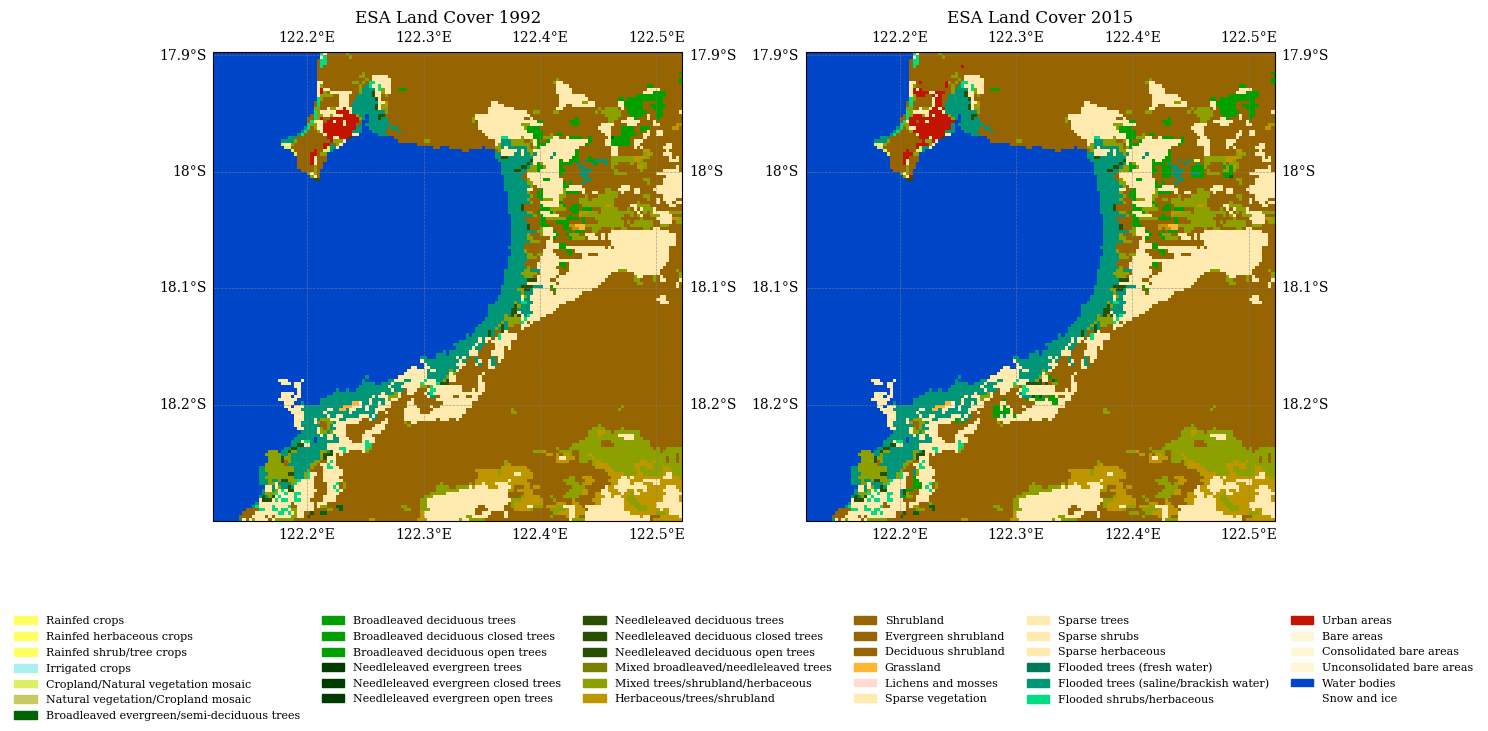

In [99]:
from livingearth_dictionary import esa_cci_lc_colours, esa_cci_lc_labels

start_year = int(start_date)
end_year = int(end_date)

year_range = range(start_year, end_year + 1)

class_ids = sorted(esa_cci_lc_labels.keys())
cmap = ListedColormap(esa_cci_lc_colours)
norm = BoundaryNorm(class_ids + [max(class_ids) + 1], ncolors=cmap.N)

# Create a figure with one column per selected year
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(years_to_plot),
    figsize=(6 * len(years_to_plot), 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Ensure axes is iterable
if len(years_to_plot) == 1:
    axes = [axes]

for ax, year in zip(axes, years_to_plot):
    print(f"Processing year {year}...")
    timestep = f"{year}-01-01"

    # Load land cover data
    lc = lc_sub["lccs_class"].sel(time=timestep, method="nearest").squeeze().compute()
    lat = lc["lat"]
    lon = lc["lon"]

    # Plot land cover
    ax.pcolormesh(lon, lat, lc.values, cmap=cmap, norm=norm, shading="auto")

    # Gridlines
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", alpha=0.7, linestyle="--")

    ax.set_title(f"ESA Land Cover {year}")

# Build a single legend for all subplots
legend_handles = [
    Patch(color=esa_cci_lc_colours[class_ids.index(cid)], label=esa_cci_lc_labels[cid])
    for cid in class_ids
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=8,
    frameon=False
)

# Adjust layout to leave space for legend
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()